# SCOPE — Redshift-space ξ(s, μ)

This notebook demonstrates `compute_xi_smu` on a uniform Poisson random field.
Because the field has no intrinsic clustering and we apply no peculiar-velocity
displacement, the true correlation function is ξ(s, μ) = 0 everywhere — this
is a clean null test showing that the SCOPE sub-volume correction leaves no
residual bias in either the monopole ξ₀(s) or the quadrupole ξ₂(s).

## Sub-volume model

Each **sub-volume** is an independent statistical realisation that spans the
**full simulation box** at 1/k of the total number density. Selecting m < k
realisations biases the auto/cross pair split; SCOPE corrects this with the
α/β weights of Hickman et al. (2026).

## RSD prescription

In a real analysis the caller applies the displacement before passing coords:
```python
z_rsd = (z_real + v_pec_z / H) % box_size   # all in Mpc/h
```
The LOS axis is z. Here we keep `v_pec = 0` so the real-space and
redshift-space positions coincide; the monopole ξ₀(s) should therefore agree
with the real-space ξ(r) from `compute_xi`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scope import compute_xi, compute_xi_smu

## 1. Simulation parameters

In [2]:
RNG_SEED  = 42
BOX_SIZE  = 542.16    # Mpc/h  (P-Millennium box)
N_FULL    = 200_000   # total galaxies across all k realisations
K         = 27        # number of independent realisations
N_MU_BINS = 100       # μ bins in [0, 1]

# 20 log-spaced bins from 1 to 50 Mpc/h
S_BINS = np.logspace(np.log10(1.0), np.log10(50.0), 21)

rng = np.random.default_rng(RNG_SEED)

## 2. Generate the full catalogue and assign sub-volume IDs

Sub-volume IDs are independent of spatial position — every realisation
samples the full box volume at mean density N/k.

In [3]:
coords_full = rng.uniform(0, BOX_SIZE, size=(N_FULL, 3)).astype(np.float64)
sv_ids_full = rng.integers(0, K, size=N_FULL, dtype=np.int32)

counts = np.bincount(sv_ids_full, minlength=K)
print(f"Full catalogue: {N_FULL:,} galaxies across {K} realisations")
print(f"Per realisation: min={counts.min()}, mean={counts.mean():.0f}, max={counts.max()}")

Full catalogue: 200,000 galaxies across 27 realisations
Per realisation: min=7191, mean=7407, max=7565


## 3. Run `compute_xi_smu` for several values of m

For each m we randomly select m realisation IDs, mask the catalogue, then
call `compute_xi_smu`. The correction weights are computed internally.

In [4]:
M_VALUES = [2, 4, 8, 27]
results  = {}

for m in M_VALUES:
    chosen = rng.choice(K, size=m, replace=False)
    mask   = np.isin(sv_ids_full, chosen)
    coords = np.ascontiguousarray(coords_full[mask])
    sv_ids = np.ascontiguousarray(sv_ids_full[mask])

    res = compute_xi_smu(
        coords             = coords,
        subvol_ids         = sv_ids,
        s_bins             = S_BINS,
        box_size           = BOX_SIZE,
        n_subvols          = K,
        n_subvols_selected = m,
        n_mu_bins          = N_MU_BINS,
        mu_max             = 1.0,
    )
    results[m] = res
    print(f"m={m:2d}  N_sel={mask.sum():6,}  "
          f"max|ξ₀| = {np.max(np.abs(res['xi0'])):.4f}  "
          f"max|ξ₂| = {np.max(np.abs(res['xi2'])):.4f}")

m= 2  N_sel=14,810  max|ξ₀| = 0.7385  max|ξ₂| = 1.2363
m= 4  N_sel=29,577  max|ξ₀| = 0.3586  max|ξ₂| = 1.0652
m= 8  N_sel=59,385  max|ξ₀| = 0.1091  max|ξ₂| = 0.6578
m=27  N_sel=200,000  max|ξ₀| = 0.0272  max|ξ₂| = 0.1896


## 4. ξ(s, μ) heatmap for m = 27

For a Poisson field with no peculiar velocities the grid should be
consistent with zero at all (s, μ). Any structure visible at small s
is shot noise from the finite catalogue.

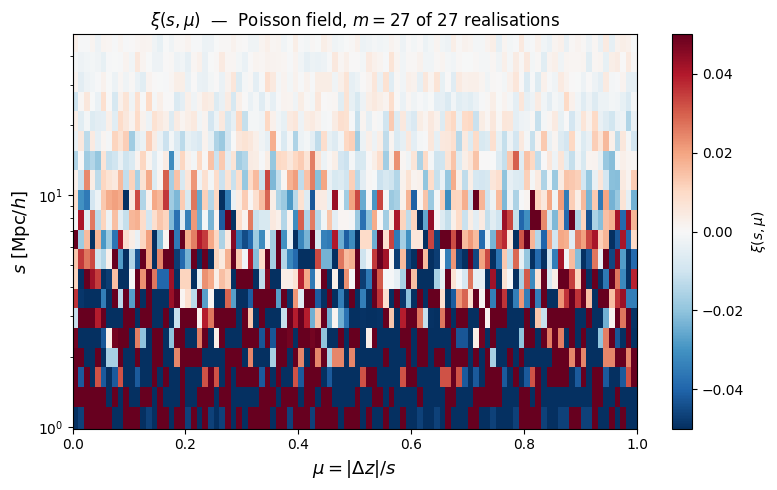

In [5]:
xi_smu = results[27]["xi_smu"]
s_mid  = results[27]["s_mid"]
mu_mid = results[27]["mu_mid"]

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.pcolormesh(
    mu_mid, s_mid, xi_smu,
    cmap="RdBu_r", vmin=-0.05, vmax=0.05,
)
ax.set_xscale("linear")
ax.set_yscale("log")
ax.set_xlabel(r"$\mu = |\Delta z| / s$", fontsize=13)
ax.set_ylabel(r"$s$ [Mpc/$h$]", fontsize=13)
ax.set_title(r"$\xi(s, \mu)$  —  Poisson field, $m = 27$ of 27 realisations",
             fontsize=12)
fig.colorbar(im, ax=ax, label=r"$\xi(s, \mu)$")
fig.tight_layout()
plt.show()

## 5. Legendre multipoles ξ₀(s) and ξ₂(s) for all m

Both multipoles should scatter around zero. The quadrupole ξ₂ is the
primary RSD observable — for a Poisson field it should vanish at all
scales regardless of m.

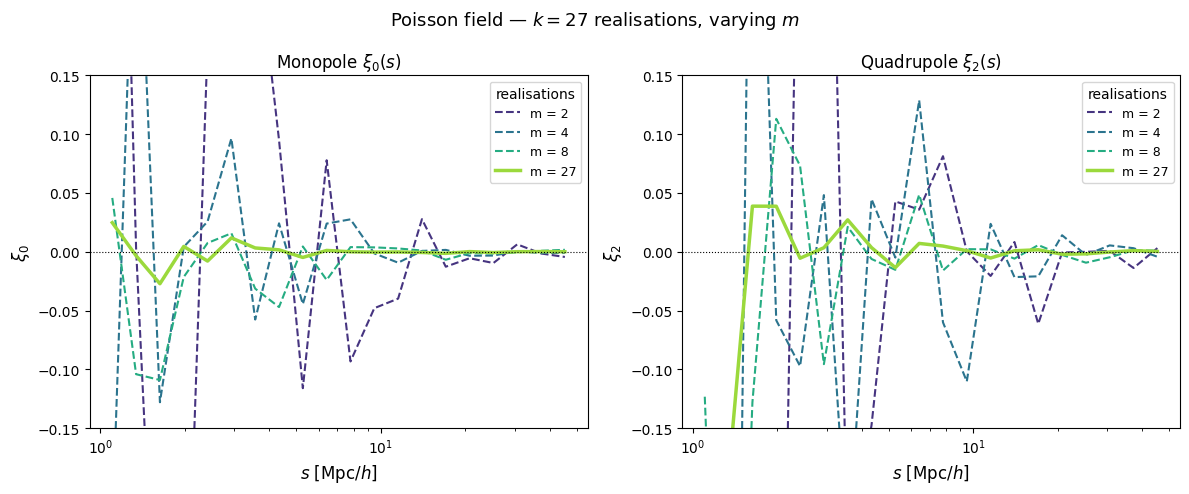

In [6]:
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(M_VALUES)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for m, col in zip(M_VALUES, colors):
    s   = results[m]["s_mid"]
    lw  = 2.5 if m == K else 1.5
    ls  = "-"  if m == K else "--"
    axes[0].semilogx(s, results[m]["xi0"], color=col, lw=lw, ls=ls, label=f"m = {m}")
    axes[1].semilogx(s, results[m]["xi2"], color=col, lw=lw, ls=ls, label=f"m = {m}")

for ax, title, ylabel in zip(
    axes,
    [r"Monopole $\xi_0(s)$", r"Quadrupole $\xi_2(s)$"],
    [r"$\xi_0$", r"$\xi_2$"],
):
    ax.axhline(0, color="k", lw=0.8, ls=":")
    ax.set_xlabel(r"$s$ [Mpc/$h$]", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.set_ylim(-0.15, 0.15)
    ax.legend(title="realisations", fontsize=9)

fig.suptitle(
    r"Poisson field — $k = 27$ realisations, varying $m$",
    fontsize=13,
)
fig.tight_layout()
plt.show()

## 6. Compare ξ₀(s) with the real-space ξ(r) from `compute_xi`

With no peculiar velocities the redshift-space positions equal the
real-space positions, so ξ(s, μ) is isotropic and the monopole
ξ₀(s) = ∫ ξ(s,μ) dμ should equal the spherically averaged ξ(r).
The two curves should overlap within shot noise.

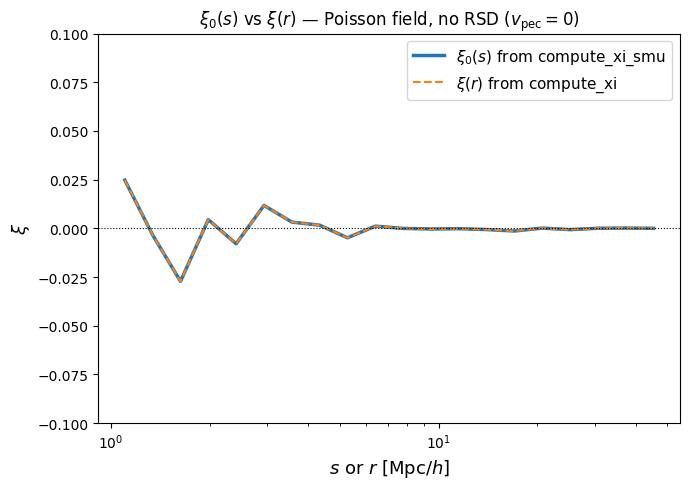

In [7]:
# Reuse the m=27 (full) selection
chosen_27 = np.arange(K, dtype=np.int32)
mask_27   = np.isin(sv_ids_full, chosen_27)   # all True
coords_27 = np.ascontiguousarray(coords_full[mask_27])
sv_27     = np.ascontiguousarray(sv_ids_full[mask_27])

res_1d = compute_xi(
    coords             = coords_27,
    subvol_ids         = sv_27,
    r_bins             = S_BINS,
    box_size           = BOX_SIZE,
    n_subvols          = K,
    n_subvols_selected = K,
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogx(results[27]["s_mid"], results[27]["xi0"],
            lw=2.5, label=r"$\xi_0(s)$ from compute_xi_smu")
ax.semilogx(res_1d["r_mid"], res_1d["xi"],
            lw=1.5, ls="--", color="C1", label=r"$\xi(r)$ from compute_xi")
ax.axhline(0, color="k", lw=0.8, ls=":")
ax.set_xlabel(r"$s$ or $r$ [Mpc/$h$]", fontsize=13)
ax.set_ylabel(r"$\xi$", fontsize=13)
ax.set_title(
    r"$\xi_0(s)$ vs $\xi(r)$ — Poisson field, no RSD ($v_\mathrm{pec} = 0$)",
    fontsize=12,
)
ax.set_ylim(-0.10, 0.10)
ax.legend(fontsize=11)
fig.tight_layout()
plt.show()

## 7. Noise convergence with m

RMS of ξ₀(s) across all bins decreases as m grows, matching the
1/√(m/k) shot-noise expectation.

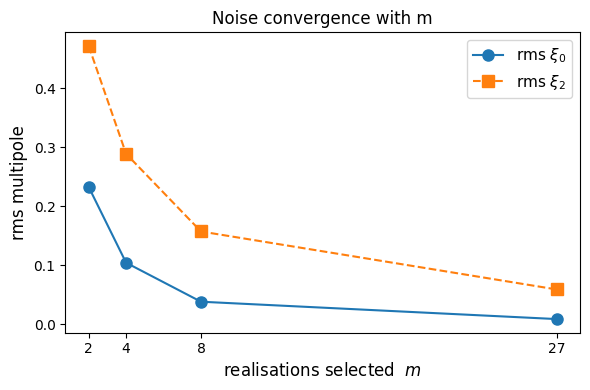

In [8]:
rms_xi0 = [np.sqrt(np.mean(results[m]["xi0"] ** 2)) for m in M_VALUES]
rms_xi2 = [np.sqrt(np.mean(results[m]["xi2"] ** 2)) for m in M_VALUES]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(M_VALUES, rms_xi0, "o-", ms=8, label=r"rms $\xi_0$")
ax.plot(M_VALUES, rms_xi2, "s--", ms=8, label=r"rms $\xi_2$")
ax.set_xlabel("realisations selected  $m$", fontsize=12)
ax.set_ylabel("rms multipole", fontsize=12)
ax.set_title("Noise convergence with m", fontsize=12)
ax.set_xticks(M_VALUES)
ax.legend(fontsize=11)
fig.tight_layout()
plt.show()